# Calculate transfer function for converting piezo recorded voltage to particle velocity


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import labseis.signal as lsig
import scipy.signal as sig
%matplotlib inline
from labseis import visual
from labseis import tiepie


In [ ]:
# Data is stored in Q2 network drive.
import os
dirc = '/Volumes/Q2/WZ/AE_LDV_Calibration/AE_LDV_Calibration_2/'
filenames = os.listdir(dirc)
filenames

['Olympus_red_1164478_1MHz_000.mat',
 'Olympus_red_1164478_1MHz_001.mat',
 'Olympus_red_1164478_1MHz_002.mat',
 'Olympus_red_1164478_1MHz_003.mat',
 'Olympus_red_1164478_1MHz_004.mat',
 'Olympus_red_1164478_1MHz_005.mat',
 'Olympus_red_1164478_1MHz_006.mat',
 'Olympus_red_1164478_1MHz_007.mat',
 'Olympus_red_1164478_1MHz_008.mat',
 'Olympus_red_1164478_1MHz_009.mat',
 'Olympus_red_1164478_1MHz_010.mat',
 'Olympus_red_1164478_1MHz_011.mat']

<Axes: title={'center': 'Sweep 0.1-100 kHz, 1000 ms duration, 10 V'}, xlabel='Time (seconds)', ylabel='Velocity (mm/s)'>

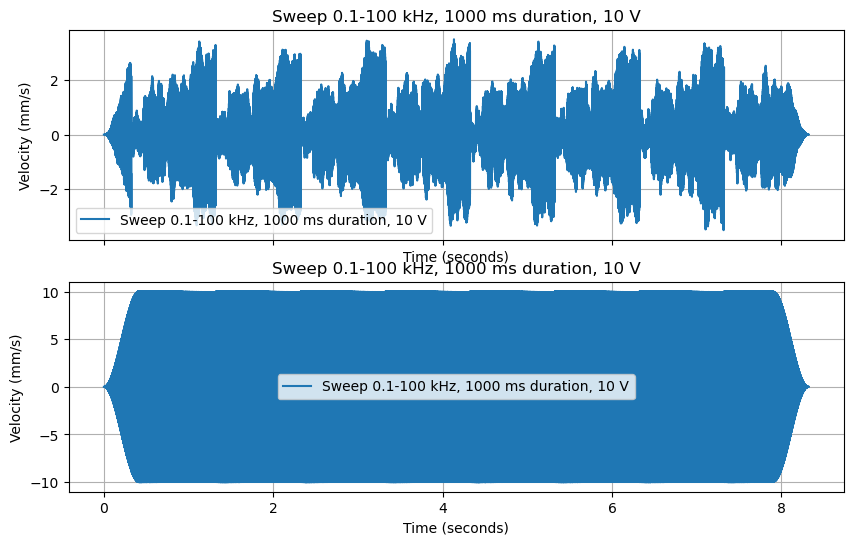

In [7]:
# Generate the time axis
meta, data_matrix = tiepie.loadAEmat(dirc+filenames[6])

sensitivity = 0.5 
velocity_data = data_matrix[0]/sensitivity
piezo_data = data_matrix[1]

num_samples = velocity_data.shape[0]  # Use the second dimension
time_axis = np.arange(num_samples) / meta['sample_frequency']

# Apply a Tukey taper to both signals before passing to the transform function
from scipy.signal import tukey

taper = tukey(len(velocity_data), alpha=0.1)

velocity_data_tapered = velocity_data * taper
piezo_data_tapered = piezo_data * taper

from scipy.signal import butter, filtfilt

# band=(100, 50000)
# fs = meta['sample_frequency']

# b, a = butter(4, [band[0]/(fs/2), band[1]/(fs/2)], btype='band')
# velocity_data_tapered = filtfilt(b, a, velocity_data_tapered)

fig, ax = plt.subplots(2,1, figsize=(10,6), sharex=True)
visual.plot_waveform(time_axis.flatten(), velocity_data_tapered.flatten(), title = 'Sweep 0.1-100 kHz, 1000 ms duration, 10 V', ax=ax[0])
visual.plot_waveform(time_axis.flatten(), piezo_data_tapered.flatten(), title = 'Sweep 0.1-100 kHz, 1000 ms duration, 10 V', ax=ax[1])


In [8]:
# taper = tukey(len(velocity_data), alpha=0.1)
# velocity_data_tapered = velocity_data * taper
# piezo_data_tapered = piezo_data * taper

H, freqs_H, fs_H = lsig.get_piezo_to_velocity_transfer_function_cross_spectrum_welch(velocity_data, piezo_data, fs=meta['sample_frequency'])


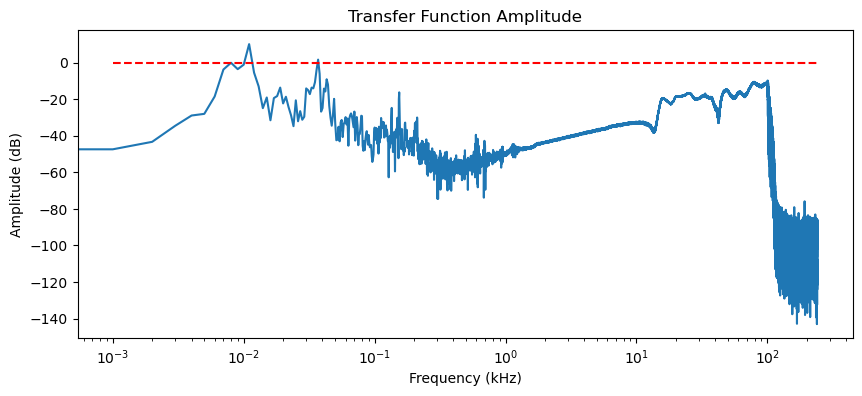

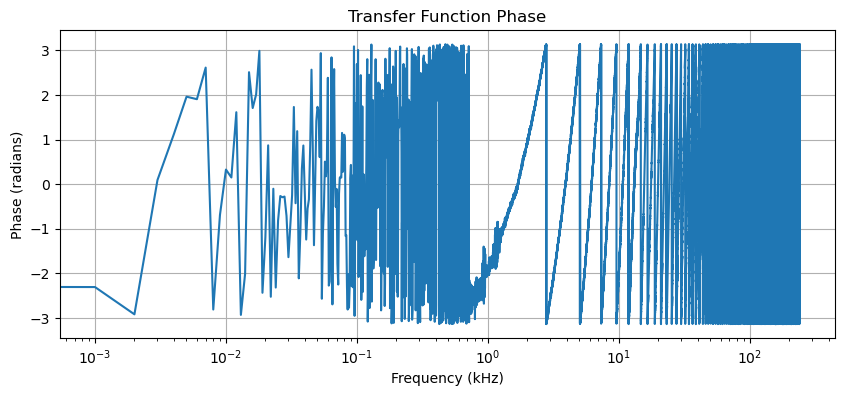

In [9]:
import matplotlib.pyplot as plt
# Amplitude response
plt.figure(figsize=(10,4))
plt.semilogx(freqs_H/1e3, 20*np.log10(np.abs(H)))
plt.hlines(0, xmin=freqs_H[1]/1e3, xmax=freqs_H[-1]/1e3, colors='r', linestyles='dashed')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Amplitude (dB)')
plt.title('Transfer Function Amplitude')
# plt.grid()

# Phase response
plt.figure(figsize=(10,4))
plt.semilogx(freqs_H/1e3, np.angle(H))
plt.xlabel('Frequency (kHz)')
plt.ylabel('Phase (radians)')
plt.title('Transfer Function Phase')
plt.grid()
plt.show()

In [11]:

# # Example: Smooth the transfer function after computing H
# H_smooth = lsig.smooth_transfer_function_gaussian(H, sigma=4)

# # Diagnostic plot: compare original and smoothed amplitude
# plt.figure(figsize=(10,4))
# plt.loglog(freqs_H, np.abs(H), label='Original')
# plt.loglog(freqs_H, np.abs(H_smooth), label='Smoothed', alpha=0.7)
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Amplitude')
# plt.title('Transfer Function Amplitude: Original vs Smoothed')
# plt.legend()
# plt.grid()
# plt.show()


In [13]:

test_data = piezo_data.copy()
taper = tukey(len(test_data), alpha=0.1)
test_data = test_data * taper
# Example usage after computing H, freqs_H:
# H_smooth = smooth_transfer_function(H, freqs_H, method='gaussian', width=100)

velocity_estimated = lsig.apply_transfer_function(test_data, H, freqs_H, fs_H, meta['sample_frequency'], filter=False).flatten()

# Use H_smooth in apply_transfer_function instead of H
# velocity_estimated_smooth = lsig.apply_transfer_function(test_data, H_smooth, freqs_H, fs_H, meta['sample_frequency'], filter=False, band=(100, 10000), order=4, eps=1e-6).flatten()

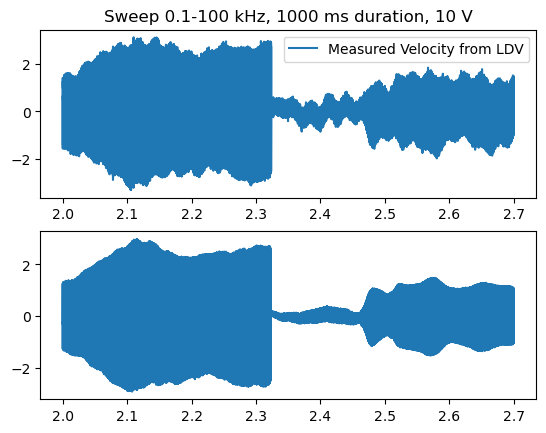

In [14]:
fig = plt.figure()
axs = fig.subplots(2)
idx = np.where((time_axis[0]>=2) & (time_axis[0]<=2.7))

# band=(100, 100000)
# fs = meta['sample_frequency']   
# b, a = butter(4, [band[0]/(fs/2), band[1]/(fs/2)], btype='band')

# axs[0].plot(time_axis[0][idx], filtfilt(b, a, velocity_data[idx]), label='Measured Velocity from LDV')
# axs[1].plot(time_axis[0][idx], filtfilt(b, a, velocity_estimated[idx]), label='Estimated Velocity from Piezo')

axs[0].plot(time_axis[0][idx], velocity_data[idx], label='Measured Velocity from LDV')
axs[1].plot(time_axis[0][idx], velocity_estimated[idx], label='Estimated Velocity from Piezo')
axs[0].set_title('Sweep 0.1-100 kHz, 1000 ms duration, 10 V')
axs[0].legend()

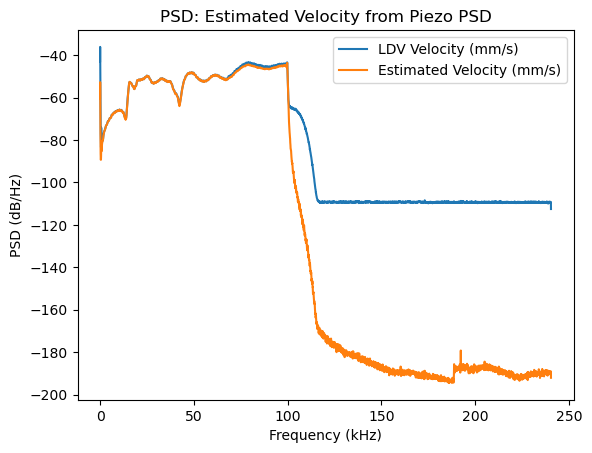

In [15]:
fig, ax = plt.subplots(1)
visual.plot_psd(velocity_data, title='LDV PSD', sample_frequency=meta['sample_frequency'], fig=fig, ax=ax, label='LDV Velocity (mm/s)')
visual.plot_psd(velocity_estimated, title='Estimated Velocity from Piezo PSD', sample_frequency=meta['sample_frequency'], fig=fig, ax=ax, label='Estimated Velocity (mm/s)')
plt.legend()
plt.show()

<Axes: title={'center': 'Sweep 0.1-100 kHz, 1000 ms duration, Piezo'}, xlabel='Time (seconds)', ylabel='velocity (mm/s)'>

/opt/miniconda3/envs/labseis/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


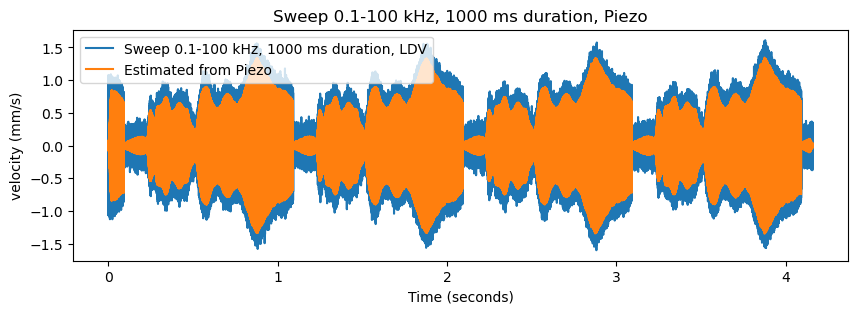

In [16]:
# Generate the time axis
meta, data_matrix = tiepie.loadAEmat(dirc+filenames[4])
sensitivity = 0.5 
velocity_data = data_matrix[0]/sensitivity
piezo_data = data_matrix[1]
taper = tukey(len(piezo_data), alpha=0.01)
piezo_data = piezo_data * taper
velocity_estimated = lsig.apply_transfer_function(piezo_data, H, freqs_H, fs_H, meta['sample_frequency'], filter=False).flatten()


num_samples = velocity_data.shape[0]  # Use the second dimension
time_axis = np.arange(num_samples) / meta['sample_frequency']

band=(1000, 100000)
fs = meta['sample_frequency']   
b, a = butter(4, [band[0]/(fs/2), band[1]/(fs/2)], btype='band')

fig, ax = plt.subplots(1, figsize=(10,3), sharex=True)
visual.plot_waveform(time_axis.squeeze(), filtfilt(b, a, velocity_data.flatten()),  title='Sweep 0.1-100 kHz, 1000 ms duration, LDV', fig=fig, ax=ax)
visual.plot_waveform(time_axis.squeeze(), filtfilt(b, a, velocity_estimated.flatten()), title='Sweep 0.1-100 kHz, 1000 ms duration, Piezo', label='Estimated from Piezo', ylabel='velocity (mm/s)', fig=fig, ax=ax)

In [17]:
np.savez('./Olympus_1164478_transfer_function.npz', H=H, freqs_H=freqs_H, fs_H=fs_H)